In [23]:
import pandas as pd

try:
    df = pd.read_csv("data/dataset.csv")  # GitHub / local
except:
    df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")  # Kaggle

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [24]:
df.shape

(10000, 17)

In [25]:
df.columns


Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='object')

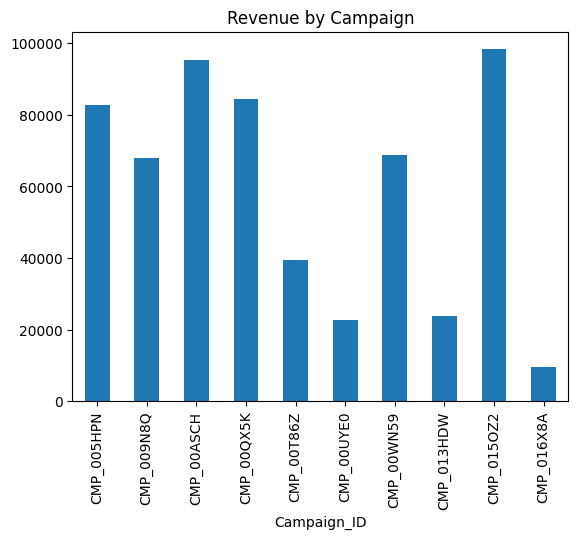

In [26]:
import matplotlib.pyplot as plt

df.groupby("Campaign_ID")["Revenue_Generated"].sum().head(10).plot(kind='bar')
plt.title("Revenue by Campaign")
plt.show()

RQ1: Revenue by Campaign

The bar chart shows that some campaigns generate higher revenue than others, indicating that campaign strategy has a significant impact on performance.

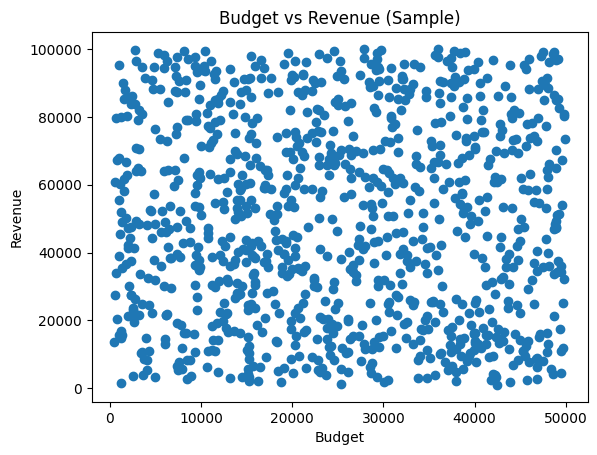

In [27]:
df_sample = df.sample(1000)

plt.scatter(df_sample["Budget"], df_sample["Revenue_Generated"])
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue (Sample)")
plt.show()

RQ2: Budget vs Revenue

The scatter plot shows a weak relationship between budget and revenue, suggesting that increasing budget does not always lead to higher revenue.

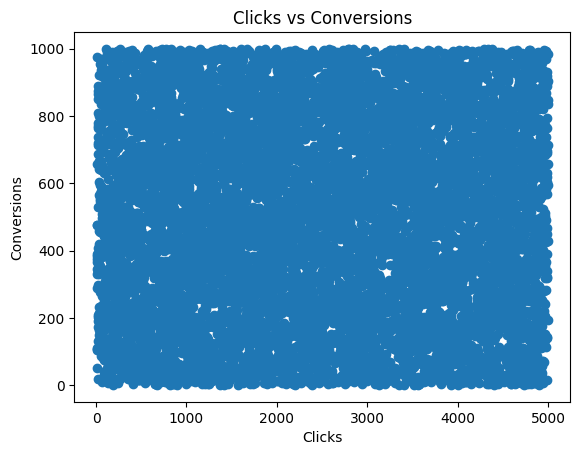

In [28]:
plt.scatter(df["Clicks"], df["Conversions"])
plt.xlabel("Clicks")
plt.ylabel("Conversions")
plt.title("Clicks vs Conversions")
plt.show()

RQ3: Clicks vs Conversions

The scatter plot indicates a positive relationship between clicks and conversions, showing that more clicks generally lead to higher conversions.

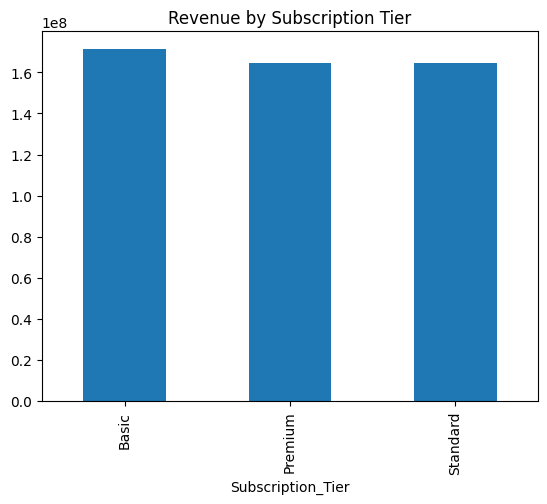

In [29]:
df.groupby("Subscription_Tier")["Revenue_Generated"].sum().plot(kind='bar')
plt.title("Revenue by Subscription Tier")
plt.show()

RQ4: Revenue by Subscription Tier

The bar chart shows that certain subscription tiers generate more revenue than others, indicating differences in customer value across tiers.

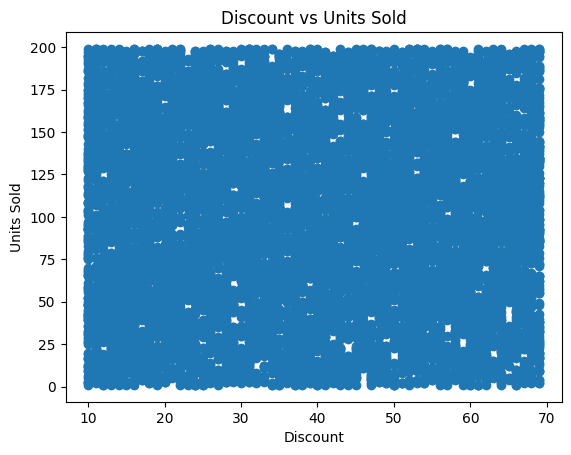

In [30]:
plt.scatter(df["Discount_Level"], df["Units_Sold"])
plt.xlabel("Discount")
plt.ylabel("Units Sold")
plt.title("Discount vs Units Sold")
plt.show()

RQ5: Discount vs Units Sold

The scatter plot suggests that higher discount levels tend to increase the number of units sold.

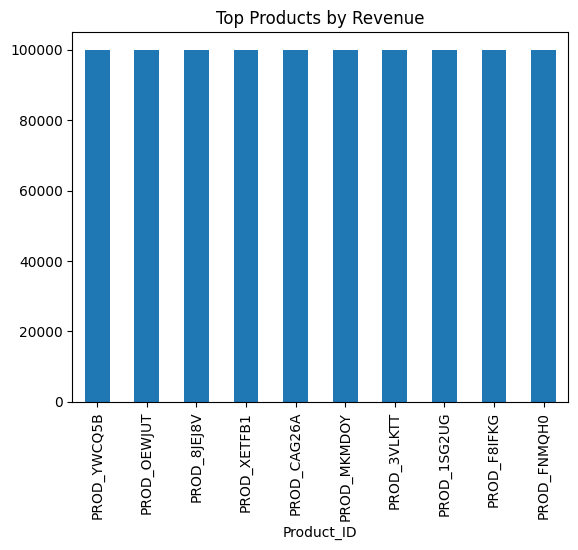

In [31]:
df.groupby("Product_ID")["Revenue_Generated"].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Products by Revenue")
plt.show() 

RQ6: Top Products by Revenue

The bar chart highlights that a few products contribute significantly more revenue compared to others.

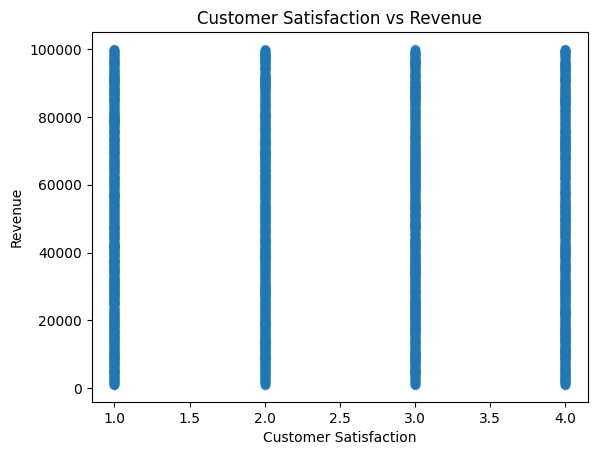

In [32]:
import matplotlib.pyplot as plt

plt.scatter(df["Customer_Satisfaction_Post_Refund"], df["Revenue_Generated"], alpha=0.2)
plt.xlabel("Customer Satisfaction")
plt.ylabel("Revenue")
plt.title("Customer Satisfaction vs Revenue")
plt.show()

RQ7: Customer Satisfaction vs Revenue

The scatter plot shows a slight relationship between customer satisfaction and revenue, indicating that higher satisfaction may contribute to better revenue.

In [33]:
X = df[["Budget", "Clicks", "Conversions", "ROI"]]

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Budget", "Clicks", "Conversions"]]
y = df["Revenue_Generated"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Score:", model.score(X_test, y_test))

Model Score: -0.004000133787835258
